In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
car_accident = pd.read_csv('/content/drive/MyDrive/Data_Science/US_Accidents_March23_sampled_500k.csv')
car_accident.head(3)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day


We will be working with 5,00,000 rows and 46 columns in this dataset.

In [ ]:
car_accident.shape

(500000, 46)

In [ ]:
car_accident.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

# **Correlation between severity and weather features**

Correlation between severity and weather features:
                 Temperature(F)  Humidity(%)  Pressure(in)  Wind_Speed(mph)  \
Temperature(F)         1.000000    -0.330141      0.120246         0.032892   
Humidity(%)           -0.330141     1.000000      0.113283        -0.171253   
Pressure(in)           0.120246     0.113283      1.000000        -0.023810   
Wind_Speed(mph)        0.032892    -0.171253     -0.023810         1.000000   
Severity              -0.017024     0.013224      0.034818         0.041100   

                 Severity  
Temperature(F)  -0.017024  
Humidity(%)      0.013224  
Pressure(in)     0.034818  
Wind_Speed(mph)  0.041100  
Severity         1.000000  


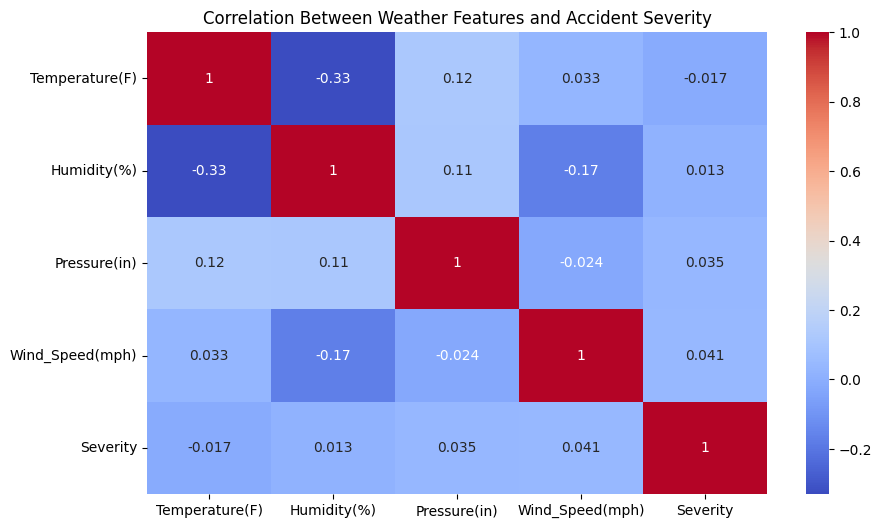

In [ ]:
# Dropping rows with missing weather information & modifying DataFrame directly
car_accident.dropna(subset=['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Wind_Speed(mph)', 'Severity'], inplace=True)

# Correlation analysis between severity and weather features
correlation_matrix = car_accident[['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Wind_Speed(mph)', 'Severity']].corr()
print("Correlation between severity and weather features:")
print(correlation_matrix)

# Heatmap visualization of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather Features and Accident Severity')
plt.show()


**The weather features hold a very weak relation in accident severity. And have no dominant influence of any single feature. Only the wind speed has the highest correlation (0.045) with Severity. Still very weak relation.**

# **Accident Severity difference between Day and Night**

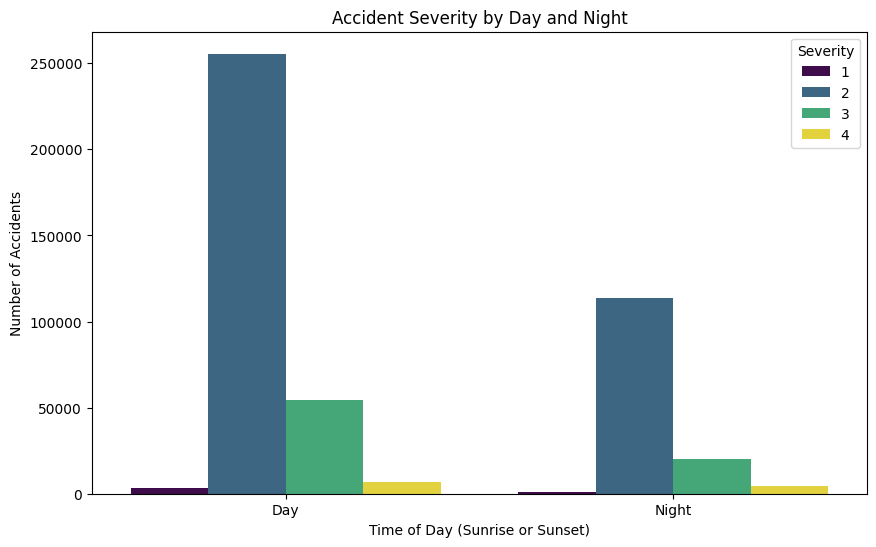

In [ ]:
# Dropping rows with missing 'Sunrise_Sunset' and 'Severity'
car_accident.dropna(subset=['Sunrise_Sunset', 'Severity'], inplace=True)

# Plot accident severity by day/night
plt.figure(figsize=(10, 6))
sns.countplot(data=car_accident, x='Sunrise_Sunset',
              hue='Severity', palette='viridis')
plt.xlabel('Time of Day (Sunrise or Sunset)')
plt.ylabel('Number of Accidents')
plt.title('Accident Severity by Day and Night')
plt.show()

**Most accidents happen during the day compared to night. Maybe it's because traffic volume is much higger during the day time. In both day and night time, Severity 2 is the dominating category. This visualization can help city planners increase safety features during daytime in high-risk areas**

# **Density difference of Accident Severity depending on Junction Presence**

<ipython-input-8-79fca230c595>:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=car_accident[car_accident['Junction'] == 'True'],
<ipython-input-8-79fca230c595>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=car_accident[car_accident['Junction'] == 'False'],


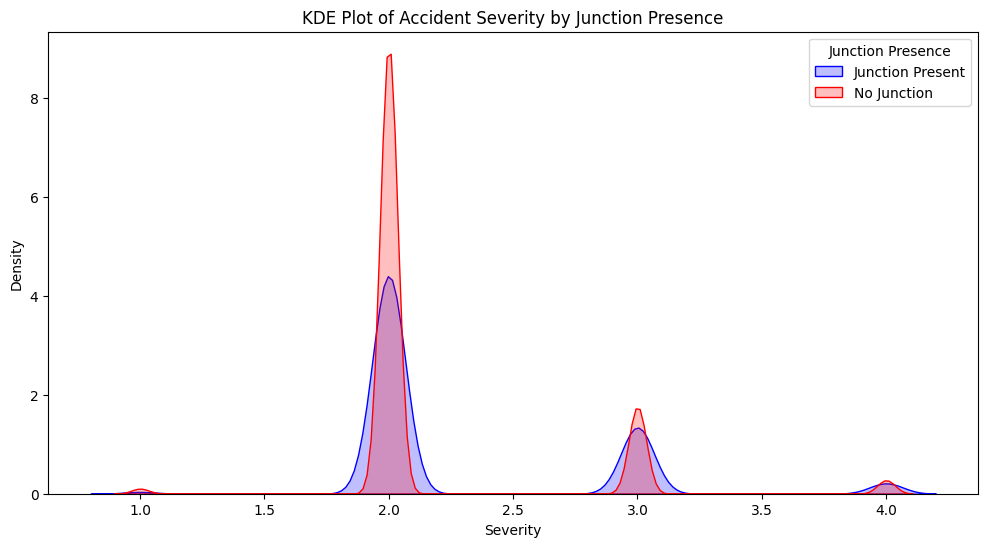

In [ ]:
# Dropping rows with missing key columns
car_accident.dropna(subset=['Junction', 'Severity'], inplace=True)

# Converting 'Junction' column into a string type.
#To treat the column as a categorical variable 'True' and 'False'.
car_accident['Junction'] = car_accident['Junction'].astype(str)

# Plotting KDE for accident severity based on junction presence
plt.figure(figsize=(12, 6))

sns.kdeplot(data=car_accident[car_accident['Junction'] == 'True'],
            x='Severity', label='Junction Present',
            shade=True, color='blue')
sns.kdeplot(data=car_accident[car_accident['Junction'] == 'False'],
            x='Severity', label='No Junction',
            shade=True, color='red')

plt.xlabel('Severity')
plt.ylabel('Density')
plt.title('KDE Plot of Accident Severity by Junction Presence')
plt.legend(title='Junction Presence')
plt.show()

**The largest density peak for both Junction Present & No Junction occurs at Severity 2 means moderately severe but not life taking; might be because of urban areas with moderate traffic speeds**

**In both cases, there are higher densities with no junctions. The city planners can implements more roundabouts to slow down the traffic and reduce collisions**

# **Number of accidents by hours of the day and days of the week to determine precautions.**

<ipython-input-9-b2ae93d00e36>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car_accident_time['Hour'] = car_accident_time['Start_Time'].dt.hour
<ipython-input-9-b2ae93d00e36>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car_accident_time['DayOfWeek'] = car_accident_time['Start_Time'].dt.day_name()


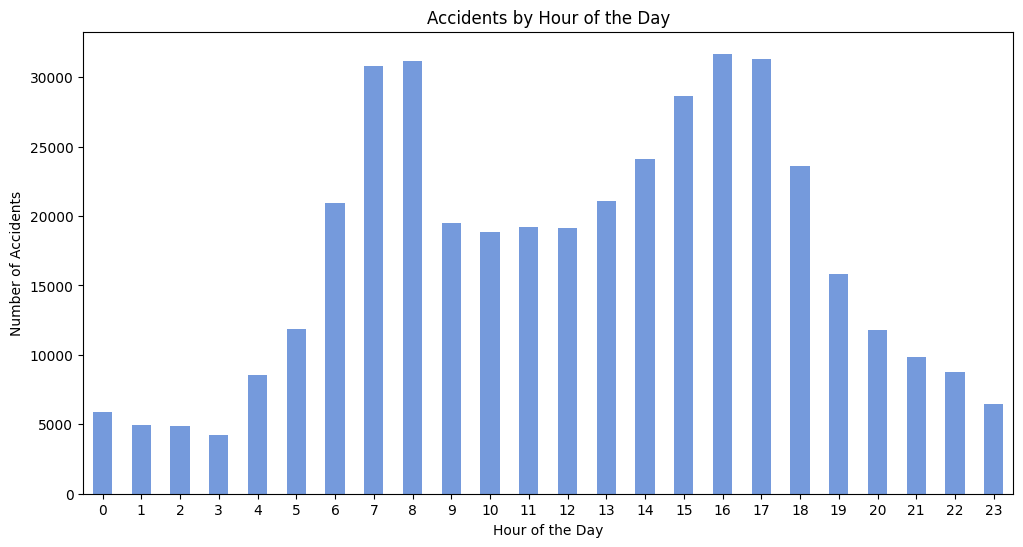

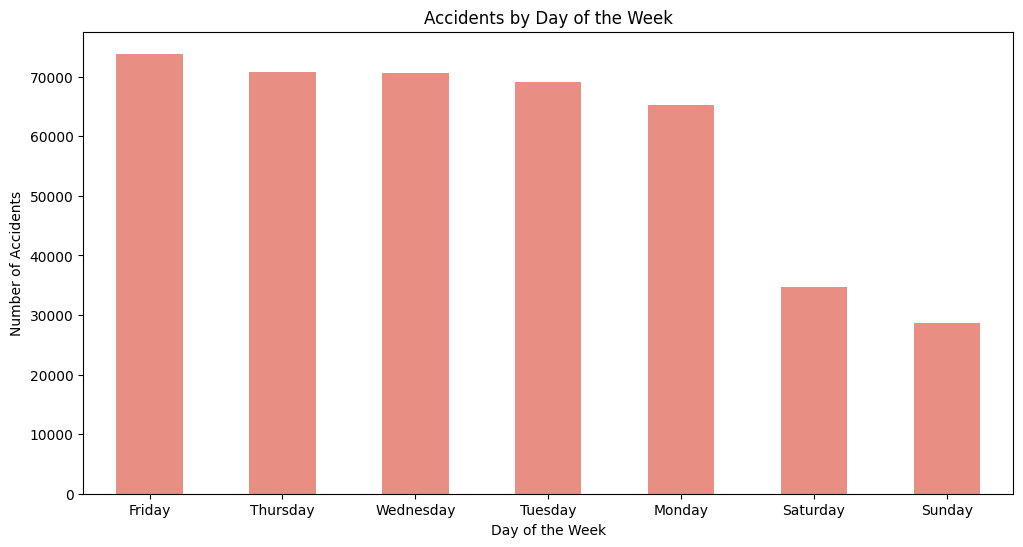

In [ ]:
# Converting 'Start_Time' to datetime and drop rows with missing values
# errors='coerce' => replacing invalid datetime with NaT

car_accident['Start_Time'] = pd.to_datetime(car_accident['Start_Time'], errors='coerce')
car_accident_time = car_accident.dropna(subset=['Start_Time'])

# Extracting temporal features & making Hour column and day of the week into DayOfWeek column
car_accident_time['Hour'] = car_accident_time['Start_Time'].dt.hour
car_accident_time['DayOfWeek'] = car_accident_time['Start_Time'].dt.day_name()


# Plotting accidents by hour of the day
plt.figure(figsize=(12, 6))
hourly_accidents = car_accident_time['Hour'].value_counts().sort_index()
#counting number of accidents for each hour & sorting index to display 0-23
sns.barplot(x=hourly_accidents.index, y=hourly_accidents.values, color='cornflowerblue', width=0.5)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.title('Accidents by Hour of the Day')
plt.show()


# Plotting accidents by day of the week
plt.figure(figsize=(12, 6))
weekday_accidents = car_accident_time['DayOfWeek'].value_counts()      #Counting number of accidents for each day of the week.
sns.barplot(x=weekday_accidents.index, y=weekday_accidents.values, color='salmon',width=0.5)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.title('Accidents by Day of the Week')
plt.show()

**The peak hour of accidents is 7-8 AM & 4-5 PM indicating heavy traffic during commuting times. Authorities can implement more road safety measures at these hours**

**There is a significant drop in accidents rates on weekends & Fridays has the most traffic accidents reports. More traffic monitoring and Patrol presences are needed on working days**

# **Top 10 Weather Conditions affecting more car accidents**

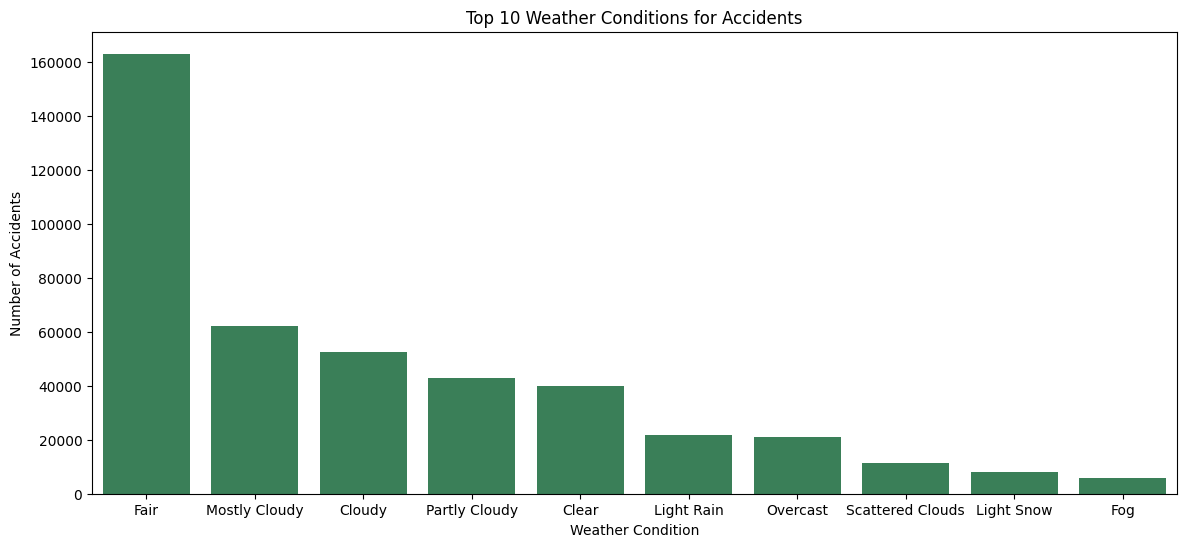

In [ ]:
# Filtering top 10 weather conditions after dropping missing rows
# nlargest(10) returning first 10 rows with the largest values in columns with ascending false

top_weather_conditions = car_accident['Weather_Condition'].dropna().value_counts().nlargest(10)

# Plotting accidents by Weather Condition using Seaborn
plt.figure(figsize=(14, 6))
sns.barplot(x=top_weather_conditions.index, y=top_weather_conditions.values, color='seagreen')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.title('Top 10 Weather Conditions for Accidents')
plt.show()


**Most accidents happen during 'Fair' weather, which means weather is not a primary factor but the driving style, and traffic density are playing more role here**

# **Visualizing accident risk category by weather, time of the day & traffic calming to aid road safety analysis**

RiskCategory
Low Risk       371190
High Risk       27903
Medium Risk     12803
Name: count, dtype: int64


<ipython-input-11-a0ed0df8d997>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='coolwarm')


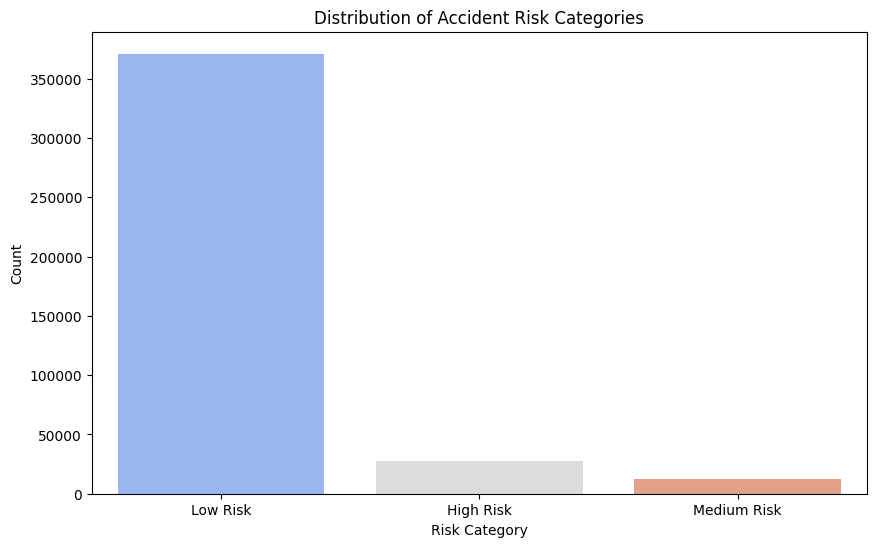

In [ ]:
# Drop rows with missing key columns
car_accident.dropna(subset=['Start_Time', 'Weather_Condition', 'Traffic_Calming',
                            'Severity'], inplace=True)

# Parsing the Start_Time column into a datetime object
#Extracting the 'Hour' from Start_time column
car_accident['Start_Time'] = pd.to_datetime(car_accident['Start_Time'], errors='coerce')
car_accident['Hour'] = car_accident['Start_Time'].dt.hour


# Defining the risk_category function based on the weather condition and hours of the day
def risk_category(row):
    high_risk_weather = {'Fair', 'Mostly Cloudy'}
    medium_risk_weather = {'Cloudy', 'Partly Cloudy'}
    high_risk_hours = {7, 8}                   # 7 - 8 AM
    medium_risk_hours = {16, 17}               # 4 - 5 PM

    if row['Weather_Condition'] in high_risk_weather and row['Hour'] in high_risk_hours and not row['Traffic_Calming']:       #Traffic calming measures are absent
        return 'High Risk'
    elif row['Weather_Condition'] in medium_risk_weather and row['Hour'] in medium_risk_hours and not row['Traffic_Calming']:
        return 'Medium Risk'
    else:
        return 'Low Risk'


# Applying the risk_category function row-wise and creating a new column named 'RiskCategory'
car_accident['RiskCategory'] = car_accident.apply(risk_category, axis=1)

# Counting occurrences of each risk category
risk_counts = car_accident['RiskCategory'].value_counts()
print(risk_counts)

# Plotting the distribution of risk categories
plt.figure(figsize=(10, 6))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='coolwarm')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.title('Distribution of Accident Risk Categories')
plt.show()


**Most accidents happen under Low Risk conditions, suggesting that risk factors like severe weather and peak hours are mostly associated with higher severity accidents.**

**While High Risk accidents are fewer in number, they may still result in more severe outcomes**

# **Geographical visualization of accidents across the USA**

In [ ]:
import folium
# Taking a random sample of 10,000 rows with valid location data
car_accident_sample = car_accident.dropna(subset=['Start_Lat', 'Start_Lng']).sample(n=10000, random_state=42)

USA_map = folium.Map(location=[39.8283, -98.5795],
                     zoom_start=5)

# Loop through each accident in the sampled dataset
for index, accident in car_accident_sample.iterrows():                                                               #not using the index currently
    folium.CircleMarker(
        location=[accident['Start_Lat'],
                  accident['Start_Lng']],                                                     # Latitude and Longitude
        radius=2, color='red',   fill=True,
        fill_color='red',
        fill_opacity=0.6).add_to(USA_map)

USA_map


**1.Urban Centers Are High-Risk Areas: Los Angeles, New York City, Miami, and Chicago have huge car accidents rates.**

**2. Heavy traffic volumns, complex road networks can be valid reasons.**

**3.The East Coast, shows a much denser pattern of accidents compared to the western regions**

**4.The red marks on the map often form linear patterns indicating major highways show frequent accidents**

**5.California, Florida, and Texas Are Critical Focus Areas in both rural & urban areas**

# **Top 10 cities with most accidents**

Top 10 Cities with Most Accidents :
             City State  Accident Count
6706        Miami    FL            9880
4904      Houston    TX            9512
6077  Los Angeles    CA            7746
1799    Charlotte    NC            7738
2507       Dallas    TX            7326
7918      Orlando    FL            5775
471        Austin    TX            5124
8680      Raleigh    NC            4831
7265    Nashville    TN            4126
617   Baton Rouge    LA            4045


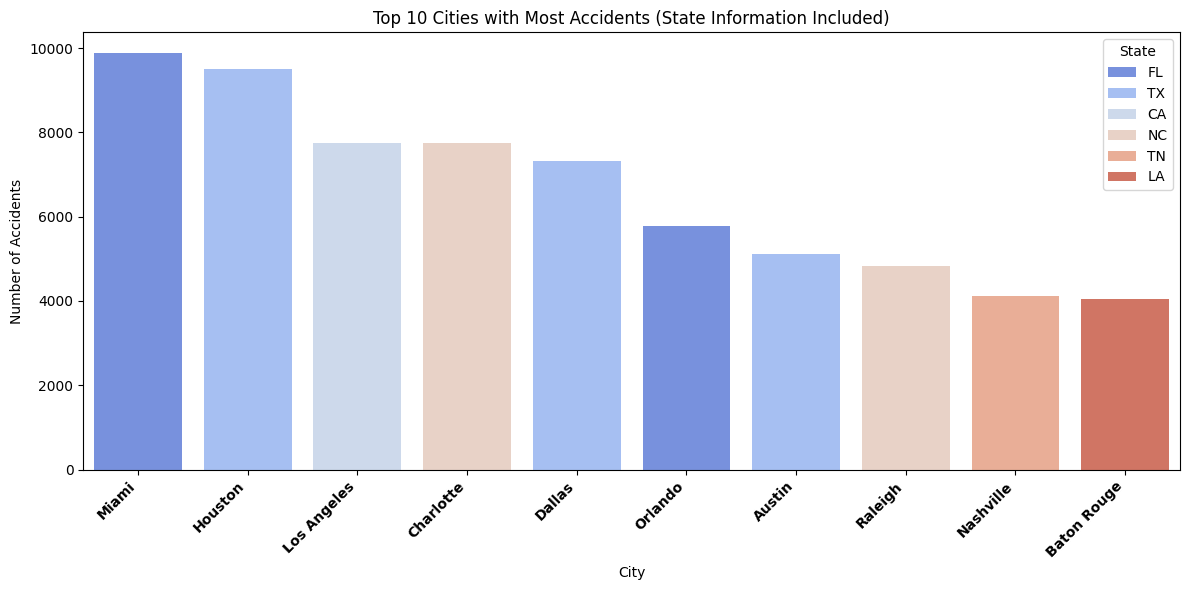

In [ ]:
# Fill missing values in 'State' with 'Unknown' to flag them for review
car_accident['State'] = car_accident['State'].fillna('Unknown')

# Group by 'City' and 'State' and count the number of accidents
city_state_grouped = car_accident.groupby(['City', 'State']).size().reset_index(name='Accident Count')

# Sort by Accident Count in descending order and select the top 10 cities
top_cities = city_state_grouped.sort_values('Accident Count', ascending=False).head(10)

# Print the top 10 cities with their states and accident counts
print("Top 10 Cities with Most Accidents :")
print(top_cities)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_cities, x='City', y='Accident Count', hue='State',  palette='coolwarm')
plt.title("Top 10 Cities with Most Accidents (State Information Included)")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold', color='black')
plt.legend(title="State", loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
missing_data = car_accident.isnull().sum()
missing_data[missing_data > 0].sort_values(ascending=True)

,0
Description,1
Wind_Direction,4
Street,526
Visibility(mi),948
Wind_Chill(F),90033
Precipitation(in),108614
End_Lat,195080
End_Lng,195080
